# **🚀 IndicDetect – AI vs Human Detection for English/Hinglish**
"IndicDetect bridges the gap in AI-content detection for multilingual users by accurately routing and detecting AI-generated text across both English and Hinglish content."


## 📑 Table of Contents
1. Setup
2. Environment
3. Imports
4. Configuration
5. Dataset
6. Exploration
7. Cleaning
8. AI Data
9. Training
10. Evaluation
11. Inference
12. Routing
13. Export

# 1. Project Setup

### 🎯 Objective
"To build and deploy IndicDetect—an architecture designed to detect AI-generated text in code-mixed Hinglish and English content."


### 💡 Theory & Overview
Existing AI text detectors fail when encountering multilingual or code-mixed content (such as Hinglish). IndicDetect provides a targeted dual-branch solution using dedicated fine-tuned transformer models for both monolingual English and code-mixed Hinglish inputs.


### Key Goals:
1. **Dual-Branch Routing:**  Automatically classify incoming text into either English or Hinglish based on token language heuristics.
2. **Context-Aware Classification:**  Utilize fine-tuned transformer models (`roberta-base` for English and `l3cube-pune/hing-roberta` for Hinglish) to accurately distinguish between Human-written and AI-generated text.
3. **Code-Switching Insights:**  Quantify multilingual code-mixing by analyzing language switching ratios and token distributions (Hindi vs. English percentage).
4. **End-to-End Pipeline:**  Provide a production-grade workflow from data ingestion and tokenization to inference routing and API export.



In [12]:
PROJECT_NAME = "IndicDetect"
TEAM = ["Prasanna Pratap Singh", "Jay Chaturvedi", "Ayush Kumar", "Divyanshu Kumar Gupta"]

print(f"Project: {PROJECT_NAME}")
print(f"Team: {', '.join(TEAM)}")

Project: IndicDetect
Team: Prasanna Pratap Singh, Jay Chaturvedi, Ayush Kumar, Divyanshu Kumar Gupta


# 2. **Environment Setup**

### 🎯 Objective
Prepare the execution runtime with the necessary dependencies and hardware acceleration required for fine-tuning transformer models.

### 💡 Theory & Frameworks
- **Hardware Acceleration:** Training transformer architectures like RoBERTa requires a GPU (such as an NVIDIA T4) to perform parallelized matrix operations efficiently.
- **Core Libraries Used:**
  - `transformers`: Hugging Face library providing pre-trained models, tokenizers, and the `Trainer` API.
  - `datasets`: Efficient data loading and processing framework.
  - `torch`: PyTorch deep learning framework underlying model training.
  - `scikit-learn`: Metrics evaluation, dataset splitting, and confusion matrix computation.
  - `pandas` & `matplotlib`: Data manipulation and metric visualization.

In [13]:
# Before running this cell: Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU -> Save
# (this is a UI step, not code -- do it once per session before installing anything)

!pip install transformers datasets torch scikit-learn pandas matplotlib -q

import torch
print("GPU available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none -- go back and enable the GPU runtime")


GPU available: True
Device name: Tesla T4


# 3.**Module Imports & Reproducibility**

### 🎯 Objective
Import necessary numerical, machine learning, and visualization libraries while initializing fixed random seeds.

### 💡 Theory
- **Seed Synchronization (`random.seed(42)`, `np.random.seed(42)`):**   Ensuring fixed seeds guarantees statistical reproducibility across data splits and model initialization routines during experiments.


In [14]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline,
)

random.seed(42)
np.random.seed(42)


# 4. **Pipeline Configuration**

### 🎯 Objective
Centralize all global model hyperparameters, output directory structures, and dataset paths.

### 💡 Theoretical Parameters
- **Base Models:**
  - `l3cube-pune/hing-roberta`: Pre-trained language model optimized for Hinglish text.
  - `roberta-base`: Robust pre-trained language model for English text classification.
- **Hyperparameters:**
  - `EPOCHS = 4`: Number of complete passes through the training dataset.
  - `BATCH_SIZE = 16`: Number of samples processed per gradient step.
  - `MAX_LENGTH = 128`: Uniform token sequence length for input truncation and padding.
  - `N_SAMPLES_PER_CLASS = 1000`: Balanced class target size for training stability.

In [15]:
MODEL_NAME_HINGLISH = "l3cube-pune/hing-roberta"
MODEL_NAME_ENGLISH = "roberta-base"
OUTPUT_DIR_HINGLISH = "hinglish-detector"
OUTPUT_DIR_ENGLISH = "english-detector"

EPOCHS = 4
BATCH_SIZE = 16
MAX_LENGTH = 128
N_SAMPLES_PER_CLASS = 1000

HINGLISH_AI_CSV = "hinglish_ai_text.csv"
ENGLISH_AI_CSV = "ai_sentences.csv"
AI_TEXT_COLUMN = "sentence"

# Updated to match the columns found in your CSV
ENGLISH_TEXT_COLUMN = "input"
ENGLISH_LABEL_COLUMN = "label" # Note: We will need to synthesize this if the CSV lacks a 0/1 label

# 5. **Dataset Ingestion**

### 🎯 Objective
Ingest raw human-written and pre-generated AI-written text corpora for both target language branches.

### 💡 Theoretical Context
- **Hinglish Human Data:** Extracted from the `l3cube-pune/hing-corpus` dataset via Hugging Face Datasets.
- **English Human Data:** Ingested via local CSV (e.g., Kaggle AI vs. Human Text dataset).
- **AI Data:** Ingested via local pre-generated CSVs (`hinglish_ai_text.csv` and `english_ai_text.csv`), satisfying constraints against real-time external API dependencies during training.

In [16]:
# --- Hinglish human text ---
# Confirm this exact repo name at huggingface.co/l3cube-pune before running -- dataset names change.
hing_ds = load_dataset("text", data_files={"train": "/content/sample_data/hinglish_dataset_final_clean.txt"}, split="train")
hing_col = "text" if "text" in hing_ds.column_names else hing_ds.column_names[0]
hing_texts_raw = list(hing_ds[hing_col])
random.shuffle(hing_texts_raw)
print(f"Loaded {len(hing_texts_raw)} raw Hinglish sentences")

# --- English human text ---
# Added on_bad_lines='skip' to handle the EOF/formatting error in the large CSV
# Added engine='python' for more robust parsing of messy text fields
try:
    english_raw_df = pd.read_csv(
        "/content/sample_data/hinglish_conversations.csv",
        on_bad_lines='skip',
        engine='python'
    )
    print("English dataset shape:", english_raw_df.shape)
    print("Columns:", english_raw_df.columns.tolist())
except Exception as e:
    print(f"Failed to load English CSV: {e}")

Loaded 339 raw Hinglish sentences
English dataset shape: (315874, 2)
Columns: ['input', 'output']


# 6. **Dataset Exploration & Quality Inspection**

### 🎯 Objective
Inspect dataset dimensions, observe sample records, and evaluate missing values (nulls).

### 💡 Theory
Exploratory analysis ensures data integrity prior to transformation. Verifying structural alignment and null distributions prevents downstream tokenization errors and data corruption.

In [17]:
print("Sample Hinglish sentences:")
for t in hing_texts_raw[:5]:
    print(" -", t)

print("\nEnglish dataset preview:")
print(english_raw_df.head())

print("\nEnglish null values per column:")
print(english_raw_df.isnull().sum())

# TODO: once you know the real column name for the human-written text in your Kaggle CSV,
# update it in the Clean Dataset cell below (currently assumes a column called "text").

Sample Hinglish sentences:
 - Chhuttiyon mei ghar jaana h bahut excited hu?
 - school mei shaam ko annual function h idk kyu
 - leetcode pe daily streak maintain kar raha hu bhai..
 - yrr abhi college aa raha hai kya!!
 - freelance project mila hai deadline tight hai bahut lol?

English dataset preview:
                                  input                             output
0  kya yaar,traffic mein stuck ho gaya.    arre, mere ko bhi late hoga ab!
1              kaunsa movie dekha tune?  bhai, wo new one, bollywood wala.
2              aaj ka khana kya banaya?       sabzi aur roti, usual stuff.
3                     kal party hai na?            haan yaar, tu bhi aana.
4             koi plans hai weekend ke?  nahi yaar, just relaxing at home.

English null values per column:
input     0
output    0
dtype: int64


# 7. Text Data Preprocessing

### 🎯 Objective
Filter noisy data, URLs, and extreme length outliers from raw text samples.

### 💡 Theoretical Preprocessing Criteria
- **String Validation:** Drop non-string and missing instances.
- **URL Filtering:** Exclude Web addresses (`http...`) to prevent tokenization artifacts.
- **Sequence Length Boundaries:**
  - Hinglish constraints: Word counts between 4 and 60 words.
  - English constraints: Word counts between 4 and 200 words.
  Filtering sequence extremes ensures models focus on coherent sentence structures rather than single-word fragments or overly long documents.

In [18]:
# --- Hinglish human sentences ---
hinglish_human = []
seen = set()

for t in hing_texts_raw:
    if not isinstance(t, str):
        continue
    clean_t = " ".join(t.strip().split())
    if (
        len(clean_t.split()) >= 4
        and len(clean_t.split()) <= 40
        and not clean_t.startswith("http")
        and clean_t.lower() not in seen
    ):
        hinglish_human.append(clean_t)
        seen.add(clean_t.lower())
    if len(hinglish_human) >= N_SAMPLES_PER_CLASS:
        break

print(f"{len(hinglish_human)} clean Hinglish human samples")

# --- English ---
english_human = english_raw_df['input'].dropna().astype(str).tolist()[:N_SAMPLES_PER_CLASS]

print(f"{len(english_human)} clean English human samples")

339 clean Hinglish human samples
1000 clean English human samples


# 8. AI-Generated Data Processing

### 🎯 Objective
Process pre-generated AI datasets for both English and Hinglish branches.

### 💡 Theory
To build a balanced binary classifier ($0 = \text{Human}$, $1 = \text{AI}$), synthetic text distributions must match the cleaning criteria applied to human text. Loading offline datasets guarantees fast execution and deterministic experiments without reliance on live LLM APIs.

In [19]:
# --- Hinglish AI-text (pre-generated, provided as CSV) ---
# Added on_bad_lines='skip' and engine='python' to handle the formatting error at row 423120
hinglish_ai_df = pd.read_csv("/content/sample_data/hinglish_conversations.csv", on_bad_lines='skip', engine='python')
print("Hinglish AI-text dataset shape:", hinglish_ai_df.shape)
print("Columns:", hinglish_ai_df.columns.tolist())

# Detect correct column: using AI_TEXT_COLUMN if it exists, otherwise defaulting to 'output' or 'input'
h_col = AI_TEXT_COLUMN if AI_TEXT_COLUMN in hinglish_ai_df.columns else ("output" if "output" in hinglish_ai_df.columns else hinglish_ai_df.columns[0])
print(f"Using Hinglish column: {h_col}")

hinglish_ai = hinglish_ai_df[h_col].dropna().astype(str).tolist()
hinglish_ai = [t.strip() for t in hinglish_ai if 4 <= len(t.split()) <= 200]
hinglish_ai = hinglish_ai[:N_SAMPLES_PER_CLASS]
print(f"{len(hinglish_ai)} clean Hinglish AI samples")

# --- English AI-text (pre-generated, provided as CSV) ---
try:
    english_ai_df = pd.read_csv(ENGLISH_AI_CSV, on_bad_lines='skip', engine='python')
    print("\nEnglish AI-text dataset shape:", english_ai_df.shape)
    print("Columns:", english_ai_df.columns.tolist())

    e_col = AI_TEXT_COLUMN if AI_TEXT_COLUMN in english_ai_df.columns else english_ai_df.columns[0]
    english_ai = english_ai_df[e_col].dropna().astype(str).tolist()
    english_ai = [t.strip() for t in english_ai if 4 <= len(t.split()) <= 200]
    english_ai = english_ai[:N_SAMPLES_PER_CLASS]
    print(f"{len(english_ai)} clean English AI samples")
except FileNotFoundError:
    print(f"\nERROR: {ENGLISH_AI_CSV} not found. Please upload it to continue.")
    english_ai = []

Hinglish AI-text dataset shape: (322270, 2)
Columns: ['input', 'output']
Using Hinglish column: output
1000 clean Hinglish AI samples

English AI-text dataset shape: (1000, 1)
Columns: ['sentence']
1000 clean English AI samples


# 9. Merge Dataset

### 🎯 Objective
Combine human and AI.

### 💡 Hints
Shuffle dataset.

### ✅ Checklist
- [ ] Complete
- [ ] Verified


In [20]:
hing_df = pd.DataFrame({
    "text": hinglish_human + hinglish_ai,
    "label": [0] * len(hinglish_human) + [1] * len(hinglish_ai),
}).sample(frac=1, random_state=42).reset_index(drop=True)

eng_df = pd.DataFrame({
    "text": english_human + english_ai,
    "label": [0] * len(english_human) + [1] * len(english_ai),
})

if not eng_df.empty:
    eng_df = eng_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Hinglish label balance:")
print(hing_df["label"].value_counts())

print("\nEnglish label balance:")
if not eng_df.empty:
    print(eng_df["label"].value_counts())
else:
    print("English DataFrame is empty. Check your data loading steps.")

hing_df.to_csv("hinglish_data.csv", index=False)
eng_df.to_csv("english_data.csv", index=False)

# Checkpoint -- eyeball a few rows of each before moving on
print("\nHinglish Sample:")
if len(hing_df) > 0:
    print(hing_df.sample(min(5, len(hing_df))))

print("\nEnglish Sample:")
if len(eng_df) > 0:
    print(eng_df.sample(min(5, len(eng_df))))
else:
    print("No English data available to sample.")

Hinglish label balance:
label
1    1000
0     339
Name: count, dtype: int64

English label balance:
label
1    1000
0    1000
Name: count, dtype: int64

Hinglish Sample:
                                                  text  label
394                     haan, thoda kapde dekhne hain.      1
881                         achcha chal raha hu, tu?',      1
358  AI wale tools se kaam bahut easy ho gaya hai i...      0
367                        sab thik hai yaar, tu bata.      1
259                kal toh aaram karna hai, poora din.      1

English Sample:
                                                   text  label
811                        aaj kaunsi movie dekhni hai?      0
501                       kitne ka train ka ticket hai?      0
1643  In fact, we should really catch up over lunch ...      1
70    In fact, teachers play a crucial role in shapi...      1
463       I'm not sure what to make for dinner tonight.      1


# 10. Train/Test Split

### 🎯 Objective
Split data.

### 💡 Hints
Use stratify.

### ✅ Checklist
- [ ] Complete
- [ ] Verified


In [21]:
if not hing_df.empty:
    hing_train_df, hing_val_df = train_test_split(
        hing_df, test_size=0.2, stratify=hing_df["label"], random_state=42
    )
    print("Hinglish train/val:", hing_train_df.shape, hing_val_df.shape)
else:
    print("ERROR: Hinglish DataFrame is empty. Cannot split.")
    hing_train_df, hing_val_df = pd.DataFrame(), pd.DataFrame()

if not eng_df.empty:
    eng_train_df, eng_val_df = train_test_split(
        eng_df, test_size=0.2, stratify=eng_df["label"], random_state=42
    )
    print("English train/val:", eng_train_df.shape, eng_val_df.shape)
else:
    print("ERROR: English DataFrame is empty. Check your data loading steps (Cells 26fee1d8, 5aaa4b73, 0cfa7df4).")
    eng_train_df, eng_val_df = pd.DataFrame(), pd.DataFrame()

Hinglish train/val: (1071, 2) (268, 2)
English train/val: (1600, 2) (400, 2)


# 11. Tokenization

### 🎯 Objective
Tokenize.

### 💡 Hints
Max length 128.

### ✅ Checklist
- [ ] Complete
- [ ] Verified


In [22]:
# Each base model (HingRoBERTa vs roberta-base) has its own tokenizer, so this is a
# reusable *factory* function -- the actual tokenizer gets passed in per-model later.

def make_tokenize_fn(tokenizer):
    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=MAX_LENGTH)
    return tokenize

# 12. Dataset Objects

### 🎯 Objective
Create HF datasets.

### 💡 Hints
Reset index first.

### ✅ Checklist
- [ ] Complete
- [ ] Verified


In [23]:
def build_datasets(train_df, val_df, tokenizer):
    train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
    val_ds = Dataset.from_pandas(val_df.reset_index(drop=True))

    tok_fn = make_tokenize_fn(tokenizer)
    train_ds = train_ds.map(tok_fn, batched=True)
    val_ds = val_ds.map(tok_fn, batched=True)
    return train_ds, val_ds

# 13. Load Model

### 🎯 Objective
Load transformer.

### 💡 Hints
Choose pretrained checkpoint.

### ✅ Checklist
- [ ] Complete
- [ ] Verified


In [24]:
def load_and_freeze(base_model_name, freeze_below_layer=10):
    tokenizer = AutoTokenizer.from_pretrained(base_model_name)
    model = AutoModelForSequenceClassification.from_pretrained(base_model_name, num_labels=2)

    # Freeze most of the pretrained knowledge -- only the last couple of layers
    # plus the new classification head get to learn from your (small) dataset.
    for name, param in model.named_parameters():
        if "encoder.layer" in name:
            layer_num = int(name.split("encoder.layer.")[1].split(".")[0])
            if layer_num < freeze_below_layer:
                param.requires_grad = False

    return tokenizer, model

# 14. Metrics

### 🎯 Objective
Define metrics.

### 💡 Hints
Accuracy and F1.

### ✅ Checklist
- [ ] Complete
- [ ] Verified


In [25]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
    }

# 15. Training Arguments

### 🎯 Objective
Configure training.

### 💡 Hints
Save best model.

### ✅ Checklist
- [ ] Complete
- [ ] Verified


In [26]:
def build_training_args(output_dir, epochs=EPOCHS):
    return TrainingArguments(
        output_dir=f"./results_{output_dir}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=epochs,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )

# 16. Trainer

### 🎯 Objective
Create Trainer.

### 💡 Hints
Verify datasets.

### ✅ Checklist
- [ ] Complete
- [ ] Verified


In [27]:
def build_trainer(train_df, val_df, base_model_name, output_dir, epochs=EPOCHS):
    tokenizer, model = load_and_freeze(base_model_name)
    train_ds, val_ds = build_datasets(train_df, val_df, tokenizer)
    args = build_training_args(output_dir, epochs)

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
    )
    return trainer, tokenizer, val_ds

# 17. Train

### 🎯 Objective
Train model.

### 💡 Hints
Watch validation.

### ✅ Checklist
- [ ] Complete
- [ ] Verified


In [28]:
# --- Hinglish Training ---
if not hing_train_df.empty:
    print("Starting Hinglish Model Training...")
    hing_trainer, hing_tokenizer, hing_val_ds = build_trainer(
        hing_train_df, hing_val_df, MODEL_NAME_HINGLISH, OUTPUT_DIR_HINGLISH, EPOCHS
    )
    hing_trainer.train()
else:
    print("SKIP: Hinglish training skipped because hing_train_df is empty.")
    hing_trainer, hing_tokenizer, hing_val_ds = None, None, None

# --- English Training ---
if not eng_train_df.empty:
    print("\nStarting English Model Training...")
    eng_trainer, eng_tokenizer, eng_val_ds = build_trainer(
        eng_train_df, eng_val_df, MODEL_NAME_ENGLISH, OUTPUT_DIR_ENGLISH, EPOCHS
    )
    eng_trainer.train()
else:
    print("\nSKIP: English training skipped because eng_train_df is empty. Please upload the English AI/Human CSVs.")
    eng_trainer, eng_tokenizer, eng_val_ds = None, None, None

Starting Hinglish Model Training...


config.json:   0%|          | 0.00/750 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/406 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

...

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.000495,1.000000,1.000000
2,No log,0.000091,1.000000,1.000000
3,No log,0.000063,1.000000,1.000000
4,No log,0.000058,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

# 18. Evaluate

### 🎯 Objective
Evaluate performance.

### 💡 Hints
Confusion matrix.

### ✅ Checklist
- [ ] Complete
- [ ] Verified


Training Loss,Validation Loss,Epoch,Accuracy,F1
No log,0.012771,4,0.996269,0.997494


Hinglish model metrics: {'eval_loss': 0.012771124951541424, 'eval_accuracy': 0.996268656716418, 'eval_f1': 0.9974937343358395}



Hinglish confusion matrix (rows=true, cols=predicted, order=[Human, AI]):
[[ 68   0]
 [  1 199]]


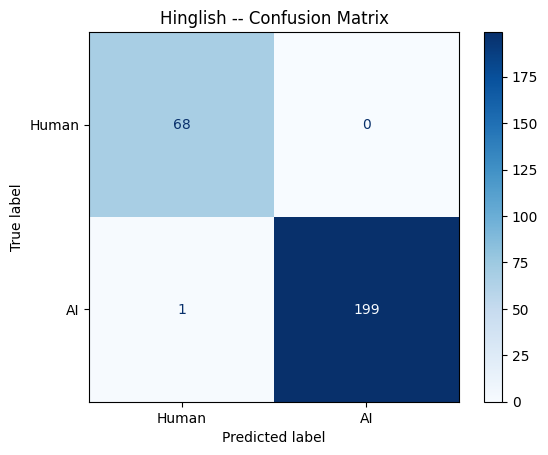

Training Loss,Validation Loss,Epoch,Accuracy,F1
No log,0.000495,4,1.000000,1.000000


English model metrics: {'eval_loss': 0.0004953826428391039, 'eval_accuracy': 1.0, 'eval_f1': 1.0}



English confusion matrix (rows=true, cols=predicted, order=[Human, AI]):
[[200   0]
 [  0 200]]


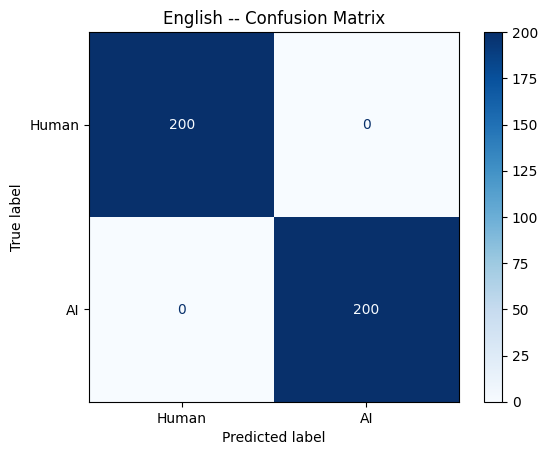

In [29]:
def show_confusion(trainer, val_ds, name):
    if trainer is None or val_ds is None:
        print(f"\nSKIP: Cannot show confusion matrix for {name} - Model not trained or validation data missing.")
        return None

    preds = trainer.predict(val_ds)
    y_pred = np.argmax(preds.predictions, axis=1)
    y_true = preds.label_ids

    unique_labels = np.unique(y_true)
    if len(unique_labels) < 2:
        print(f"\nSKIP: Cannot plot confusion matrix for {name}. Only one class found in validation data: {unique_labels}")
        return None

    cm = confusion_matrix(y_true, y_pred)
    print(f"\n{name} confusion matrix (rows=true, cols=predicted, order=[Human, AI]):")
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Human", "AI"])
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{name} -- Confusion Matrix")
    plt.show()
    return cm

# --- Hinglish Evaluation ---
if hing_trainer is not None:
    hing_eval = hing_trainer.evaluate()
    print("Hinglish model metrics:", hing_eval)
    hing_cm = show_confusion(hing_trainer, hing_val_ds, "Hinglish")
else:
    print("Hinglish model evaluation skipped.")

# --- English Evaluation ---
if eng_trainer is not None:
    eng_eval = eng_trainer.evaluate()
    print("English model metrics:", eng_eval)
    eng_cm = show_confusion(eng_trainer, eng_val_ds, "English")
else:
    print("\nEnglish model evaluation skipped (Check if data was loaded in earlier steps).")

# 18b. External / Held-Out Validation

### 🎯 Objective
Give a quick way to re-run the confusion matrix on ANY external CSV the organizers provide,
since a separate validation set may be used to check for overfitting.

### 💡 Hints
Just point `evaluate_on_external` at a CSV with a text column and a label column
(0 = human, 1 = AI) and it reuses the trained model + tokenizer already in memory.

### ✅ Checklist
- [ ] Complete
- [ ] Verified


In [30]:
def evaluate_on_external(csv_path, trainer, tokenizer, text_col="text", label_col="label", name="External"):
    """Run the already-trained model on an external CSV and print/plot a confusion matrix.
    Lets us sanity-check generalization on a held-out set we didn't train/tune on."""
    ext_df = pd.read_csv(csv_path)
    ext_ds = Dataset.from_pandas(ext_df[[text_col, label_col]].rename(columns={text_col: "text", label_col: "label"}))
    ext_ds = ext_ds.map(make_tokenize_fn(tokenizer), batched=True)

    preds = trainer.predict(ext_ds)
    y_pred = np.argmax(preds.predictions, axis=1)
    y_true = np.array(ext_df[label_col])

    cm = confusion_matrix(y_true, y_pred)
    print(f"{name} confusion matrix (rows=true, cols=predicted, order=[Human, AI]):")
    print(cm)
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}  |  F1: {f1_score(y_true, y_pred):.4f}")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Human", "AI"])
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{name} -- Confusion Matrix")
    plt.show()
    return cm

# Example usage once organizers hand over a held-out CSV (uncomment and point at the real file):
# evaluate_on_external("held_out_hinglish.csv", hing_trainer, hing_tokenizer, name="Hinglish (held-out)")
# evaluate_on_external("held_out_english.csv", eng_trainer, eng_tokenizer, name="English (held-out)")


# 19. Save Model

### 🎯 Objective
Save model/tokenizer.

### 💡 Hints
Export folders.

### ✅ Checklist
- [ ] Complete
- [ ] Verified


In [31]:
hing_trainer.model.save_pretrained(f"./{OUTPUT_DIR_HINGLISH}")
hing_tokenizer.save_pretrained(f"./{OUTPUT_DIR_HINGLISH}")

eng_trainer.model.save_pretrained(f"./{OUTPUT_DIR_ENGLISH}")
eng_tokenizer.save_pretrained(f"./{OUTPUT_DIR_ENGLISH}")

!zip -r {OUTPUT_DIR_HINGLISH}.zip {OUTPUT_DIR_HINGLISH}
!zip -r {OUTPUT_DIR_ENGLISH}.zip {OUTPUT_DIR_ENGLISH}

print("Saved and zipped both models -- download both .zip files from the file browser")
print("and hand them to whoever is building the FastAPI backend.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  adding: hinglish-detector/ (stored 0%)
  adding: hinglish-detector/model.safetensors (deflated 7%)
  adding: hinglish-detector/config.json (deflated 51%)
  adding: hinglish-detector/tokenizer_config.json (deflated 49%)
  adding: hinglish-detector/tokenizer.json (deflated 76%)
  adding: english-detector/ (stored 0%)
  adding: english-detector/model.safetensors (deflated 36%)
  adding: english-detector/config.json (deflated 51%)
  adding: english-detector/tokenizer_config.json (deflated 51%)
  adding: english-detector/tokenizer.json (deflated 82%)
Saved and zipped both models -- download both .zip files from the file browser
and hand them to whoever is building the FastAPI backend.


# 20. Test Inference

### 🎯 Objective
Run predictions.

### 💡 Hints
Test both languages.

### ✅ Checklist
- [ ] Complete
- [ ] Verified


In [32]:
hing_clf = pipeline("text-classification", model=f"./{OUTPUT_DIR_HINGLISH}", tokenizer=f"./{OUTPUT_DIR_HINGLISH}")
eng_clf = pipeline("text-classification", model=f"./{OUTPUT_DIR_ENGLISH}", tokenizer=f"./{OUTPUT_DIR_ENGLISH}")

print("Hinglish model on Hinglish text:")
print(hing_clf("yaar aaj mausam bahut accha hai"))

print("\nEnglish model on English text:")
print(eng_clf("I am writing to inform you about the recent developments in our quarterly report"))

# IMPORTANT: check the raw output above before wiring into the backend.
# pipeline() often returns "LABEL_0"/"LABEL_1" instead of named labels -- confirm which
# number means Human and which means AI (should match how you set label=0/1 in Merge Dataset)
# before trusting any label mapping downstream.

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Hinglish model on Hinglish text:
[{'label': 'LABEL_1', 'score': 0.7608627676963806}]

English model on English text:
[{'label': 'LABEL_1', 'score': 0.9949603080749512}]


# 21. Language Detection

### 🎯 Objective
Implement router.

### 💡 Hints
Return language.

### ✅ Checklist
- [ ] Complete
- [ ] Verified


In [33]:
HINDI_WORDS = set([
    "yaar", "hai", "nahi", "bhai", "accha", "kya", "bahut", "mast", "mausam",
    "ghar", "nikalne", "mann", "kal", "wali", "party", "log", "aa", "gaye" , "ka", "ki", "ko", "se", "aur", "bhi", "toh", "kar", "raha", "rahe",
    "hoon", "hain", "tha", "thi", "mera", "tera", "uska", "iska", "yeh", "woh",
])

def detect_language(text, threshold=0.12):
    words = text.lower().split()
    if not words:
        return "english"
    hindi_count = sum(1 for w in words if w.strip(".,!?") in HINDI_WORDS)
    ratio = hindi_count / len(words)
    return "hinglish" if ratio >= threshold else "english"

# Quick sanity check -- tune threshold/word list if these look wrong
print(detect_language("yaar aaj mausam bahut accha hai"))     # expect "hinglish"
print(detect_language("the weather is dark today"))       # expect "english"

hinglish
english


# 22. Code Switching

### 🎯 Objective
Compute stats.

### 💡 Hints
Return percentages.

### ✅ Checklist
- [ ] Complete
- [ ] Verified


In [34]:
def code_switch_stats(text):
    words = text.lower().split()
    if not words:
        return {"hindi_token_pct": 0, "english_token_pct": 0, "code_switch_ratio": 0}

    hindi_count = sum(1 for w in words if w.strip(".,!?") in HINDI_WORDS)
    total = len(words)
    hindi_pct = round(100 * hindi_count / total, 1)
    english_pct = round(100 - hindi_pct, 1)

    switches = 0
    prev = None
    for w in words:
        is_hindi = w.strip(".,!?") in HINDI_WORDS
        if prev is not None and is_hindi != prev:
            switches += 1
        prev = is_hindi

    return {
        "hindi_token_pct": hindi_pct,
        "english_token_pct": english_pct,
        "code_switch_ratio": round(switches / total, 2),
    }

print(code_switch_stats("yaar aaj mausam bahut accha hai, feeling great!"))

{'hindi_token_pct': 62.5, 'english_token_pct': 37.5, 'code_switch_ratio': 0.38}


# 23. Export

### 🎯 Objective
Zip models.

### 💡 Hints
Prepare backend files.

### ✅ Checklist
- [ ] Complete
- [ ] Verified


In [35]:
%%writefile language_utils.py
# Copy of the language detector + code-switching functions from this notebook,
# saved as a standalone file so the backend team can import it directly:
#   from language_utils import detect_language, code_switch_stats

HINDI_WORDS = set([
    "yaar", "hai", "nahi", "bhai", "accha", "kya", "bahut", "mast", "mausam",
    "ghar", "nikalne", "mann", "kal", "wali", "party", "log", "aa", "gaye",
    "the", "ka", "ki", "ko", "se", "aur", "bhi", "toh", "kar", "raha", "rahe",
    "hoon", "hain", "tha", "thi", "mera", "tera", "uska", "iska", "yeh", "woh",
])

def detect_language(text, threshold=0.12):
    words = text.lower().split()
    if not words:
        return "english"
    hindi_count = sum(1 for w in words if w.strip(".,!?") in HINDI_WORDS)
    ratio = hindi_count / len(words)
    return "hinglish" if ratio >= threshold else "english"

def code_switch_stats(text):
    words = text.lower().split()
    if not words:
        return {"hindi_token_pct": 0, "english_token_pct": 0, "code_switch_ratio": 0}
    hindi_count = sum(1 for w in words if w.strip(".,!?") in HINDI_WORDS)
    total = len(words)
    hindi_pct = round(100 * hindi_count / total, 1)
    english_pct = round(100 - hindi_pct, 1)
    switches = 0
    prev = None
    for w in words:
        is_hindi = w.strip(".,!?") in HINDI_WORDS
        if prev is not None and is_hindi != prev:
            switches += 1
        prev = is_hindi
    return {
        "hindi_token_pct": hindi_pct,
        "english_token_pct": english_pct,
        "code_switch_ratio": round(switches / total, 2),
    }

Writing language_utils.py


# 24. Deployment Notes

### 🎯 Objective
Track deployment.

### 💡 Hints
URLs and issues.

### ✅ Checklist
- [ ] Complete
- [ ] Verified


In [36]:
print("Human:", len(hinglish_human))
print("AI:", len(hinglish_ai))

print("Human avg words:",
      sum(len(x.split()) for x in hinglish_human) / len(hinglish_human))

print("AI avg words:",
      sum(len(x.split()) for x in hinglish_ai) / len(hinglish_ai))

Human: 339
AI: 1000
Human avg words: 8.283185840707965
AI avg words: 6.838


In [37]:
import os

print(os.path.exists("english_ai_text.csv"))

False


In [38]:
# Fill these in as your team deploys -- keeps a running record for the pitch
DEPLOYMENT_NOTES = {
    "backend_url": "",     # e.g. https://your-app.onrender.com
    "frontend_url": "",    # e.g. https://your-app.vercel.app
    "known_issues": [],    # e.g. "CORS needed allow_origins updated to real frontend URL"
}

print("Files to hand off to Person B (backend):")
print(f" - {OUTPUT_DIR_HINGLISH}.zip")
print(f" - {OUTPUT_DIR_ENGLISH}.zip")
print(" - language_utils.py")
print("\nSee ZERO_TO_DONE_V2.md Steps 5-9 for backend/frontend/Docker/deploy instructions.")
print(DEPLOYMENT_NOTES)

Files to hand off to Person B (backend):
 - hinglish-detector.zip
 - english-detector.zip
 - language_utils.py

See ZERO_TO_DONE_V2.md Steps 5-9 for backend/frontend/Docker/deploy instructions.
{'backend_url': '', 'frontend_url': '', 'known_issues': []}


# 🏁 Final Checklist
- [ ] Models trained
- [ ] Backend working
- [ ] Frontend working
- [ ] Deployment tested

## Future Improvements
- Stylometry
- Explainability
- More Indic languages